In [14]:
# Packages
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import warnings
import pandas as pd
from IPython.display import display

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample

from time import perf_counter

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy

The Data

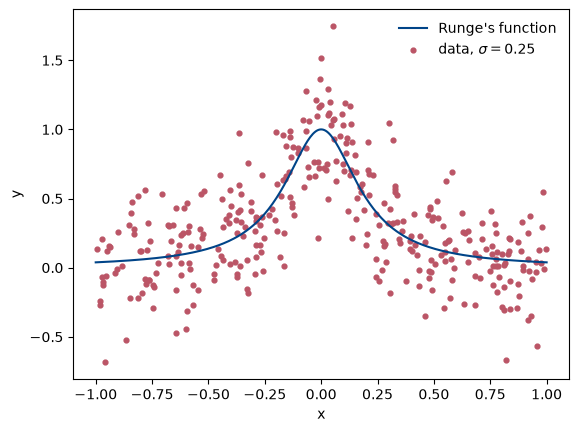

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

rng = np.random.default_rng(2026)
n = 350
sigma = 0.25                                  # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

xx = np.linspace(-1, 1, n)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()

# a: Ordinary Least Squares 

In [16]:
# Your code for part a) here
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

maxdeg = 15
deg_V = np.arange(maxdeg + 1)
MSE_V = []
R2_V = []
Parameter_V = []
Prediction_V = []

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Konstantkolonnen skal fortsatt være lik 1.
    mean[0] = 0.0
    std[0] = 1.0
    X_train_c = (X_train - mean) / std
    X_test_c = (X_test - mean) / std

    theta = np.linalg.pinv(X_train_c) @ y_train
    Parameter_V.append(theta)

    # Bruk treningsmodellens normalisering for hver grads prediksjonskurve.

    X_plot = design_matrix(xx, degree)
    X_plot_scaled = (X_plot - mean) / std
    Prediction_V.append(X_plot_scaled @ theta)

    y_predict = X_test_c @ theta
    mse = np.mean((y_test - y_predict)**2)
    MSE_V.append(mse)

    y_mean = np.mean(y_test)
    R2 = 1 - (np.sum((y_test - y_predict)**2))/(np.sum((y_test - y_mean)**2))
    R2_V.append(R2)

OLS_5D_theta = Parameter_V[5]
print(OLS_5D_theta)


[ 0.30464391  0.06182422 -0.70568613 -0.23206994  0.51242763  0.17121206]


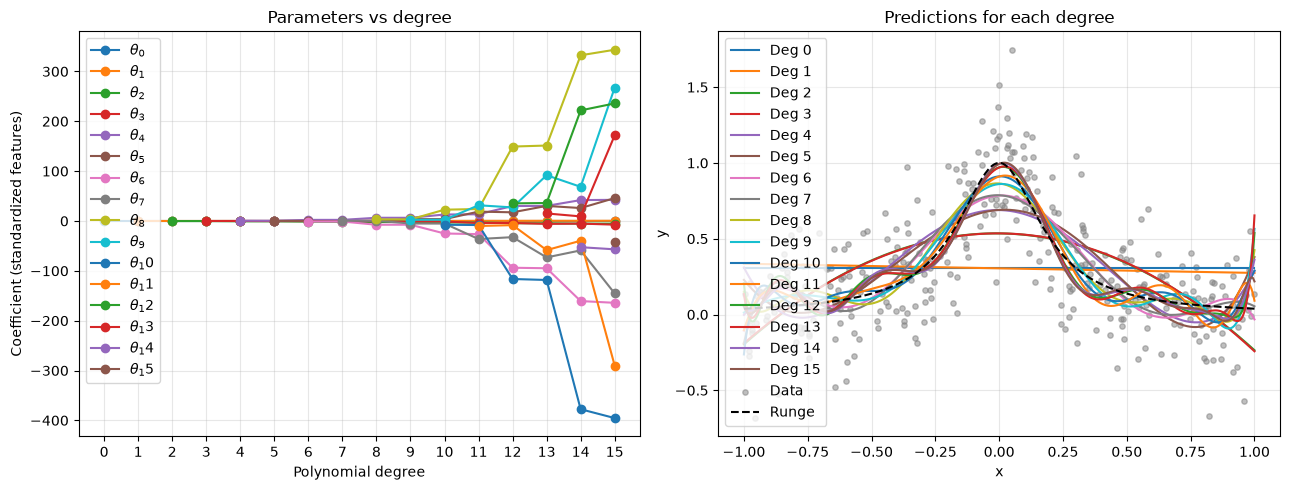

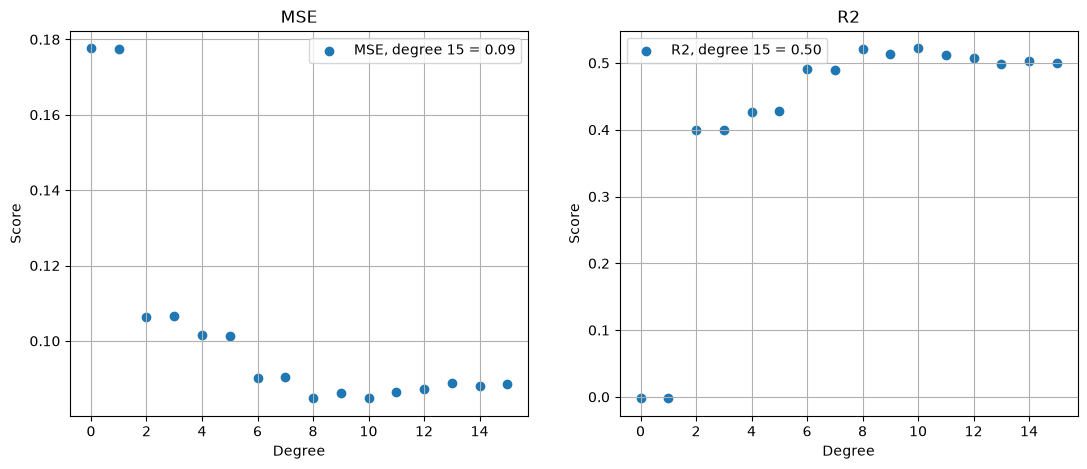

In [17]:
fig, (ax_parameters, ax_predictions) = plt.subplots(1, 2, figsize=(13, 5))

# Grad d har d + 1 parametre. NaN markerer parametre modellen ikke har.
parameters = np.full((maxdeg + 1, maxdeg + 1), np.nan)
for degree, theta in enumerate(Parameter_V):
    parameters[degree, :len(theta)] = theta
    ax_predictions.plot(xx, Prediction_V[degree], label=f"Deg {degree}")

for j in range(maxdeg + 1):
    ax_parameters.plot(deg_V, parameters[:, j], marker="o", label=rf"$\theta_{j}$")

ax_parameters.set(title="Parameters vs degree", xlabel="Polynomial degree",
                  ylabel="Coefficient (standardized features)")
ax_parameters.set_xticks(deg_V)
ax_parameters.legend()
ax_parameters.grid(alpha=0.3)

ax_predictions.scatter(x, y, s=15, color="gray", alpha=0.5, label="Data")
ax_predictions.plot(xx, runge(xx), "k--", label="Runge")
ax_predictions.set(title="Predictions for each degree", xlabel="x", ylabel="y")
ax_predictions.legend()
ax_predictions.grid(alpha=0.3)
fig.tight_layout()
#plt.ylim(-0.25,1.1)
plt.show()

#  R2 og MSE
fix, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.scatter(deg_V, MSE_V, label = f"MSE, degree {maxdeg} = {MSE_V[-1]:.2f}")
ax2.scatter(deg_V, R2_V, label = f"R2, degree {maxdeg} = {R2_V[-1]:.2f}")
ax1.set_xlabel("Degree"), ax1.set_ylabel("Score")
ax2.set_xlabel("Degree"), ax2.set_ylabel("Score")
ax1.legend(), ax2.legend()
ax1.grid(), ax2.grid()
ax1.set_title("MSE"), ax2.set_title("R2")
plt.show()

# b: Ridge Regression

In [18]:
#lambdas = [1e-2, 1e-1, 0.5, 1.0, 1e1]
lambdas = np.logspace(-3, 2, 5)
MSE_grid = np.zeros((maxdeg + 1, len(lambdas)))
R2_grid = np.zeros((maxdeg + 1, len(lambdas)))

for degree in range(maxdeg + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    # Beregn gjennomsnitt og standardavvik fra treningsdata
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Behold konstantkolonnen: (1 - 0) / 1 = 1
    mean[0] = 0
    std[0] = 1

    X_train_norm = (X_train - mean) / std
    X_test_norm = (X_test - mean) / std
    # Trenger ikke sentrere y da design matrisen inneholder intercept

    #X_train_norm = X_train 
    #X_test_norm = X_test


    for i, lmb in enumerate(lambdas):
        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke at intercept skal bli straffet av Ridge
        
        theta = np.linalg.pinv((X_train_norm).T @ (X_train_norm) + lmb*I) @ (X_train_norm).T @ y_train
        if degree == 5 and lmb == 1e-2:
            #print(theta)
            Ridge_5D_theta = theta
        
        y_predict = X_test_norm @ theta
        mse = np.mean((y_test - y_predict)**2)
        #MSE_V.append(mse)

        y_predict = X_test_norm @ theta 
        MSE_grid[degree, i] = np.mean((y_test - y_predict)**2)
        y_mean = np.mean(y_test)
        R2_grid[degree, i] = 1 - np.sum((y_test - y_predict)**2) / np.sum((y_test - y_mean)**2)

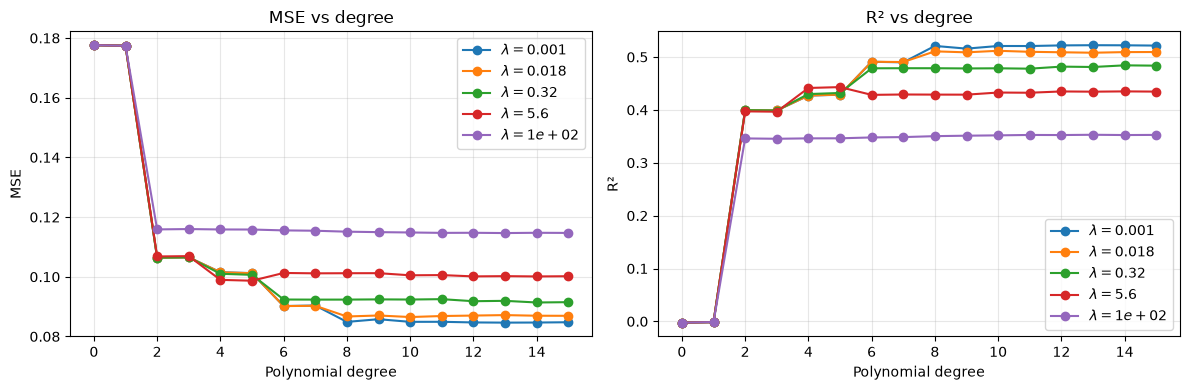

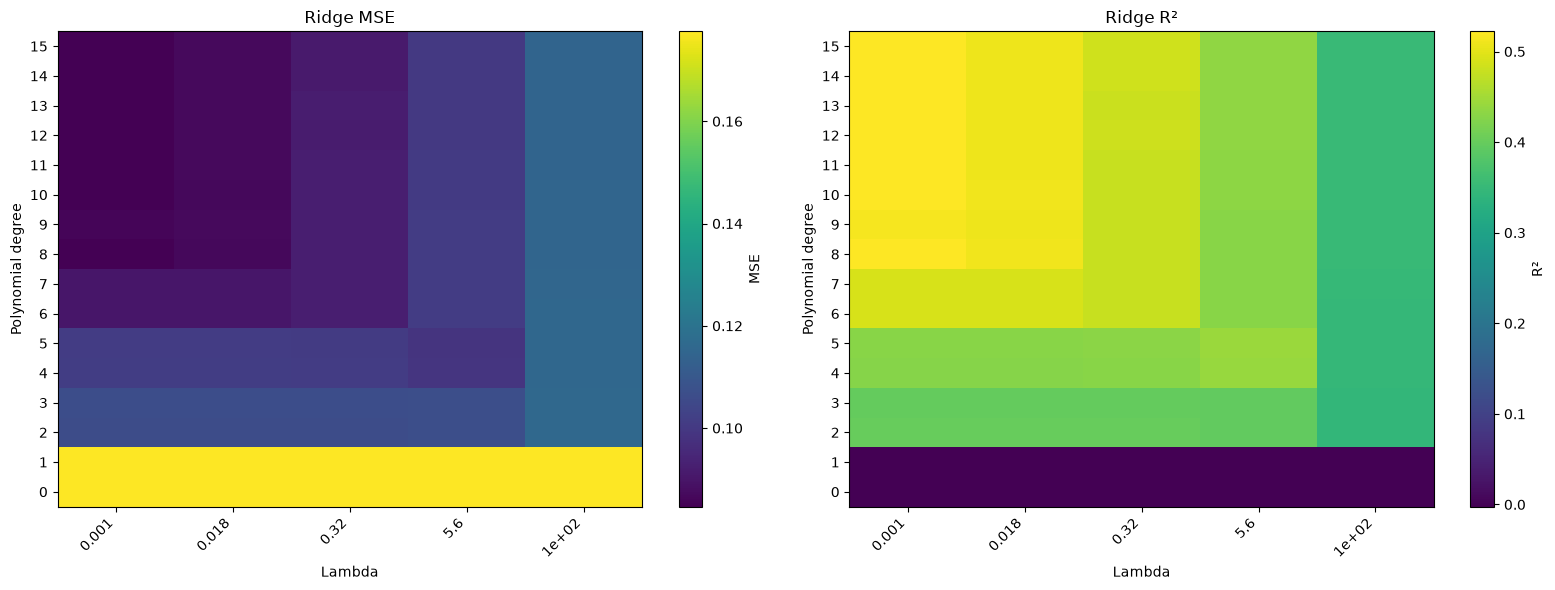

In [19]:
# b) plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, lam in enumerate(lambdas):
    axes[0].plot(deg_V, MSE_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")
    axes[1].plot(deg_V, R2_grid[:, i], marker="o", label=rf"$\lambda={lam:.2g}$")

axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs degree")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("R²")
axes[1].set_title("R² vs degree")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# MSE heatmap
im1 = axes[0].imshow(MSE_grid, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Ridge MSE")
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Polynomial degree")
axes[0].set_xticks(np.arange(len(lambdas)))
axes[0].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[0].set_yticks(np.arange(maxdeg + 1))
axes[0].set_yticklabels(deg_V)
fig.colorbar(im1, ax=axes[0], label="MSE")

# R² heatmap
im2 = axes[1].imshow(R2_grid, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Ridge R²")
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Polynomial degree")
axes[1].set_xticks(np.arange(len(lambdas)))
axes[1].set_xticklabels([f"{lam:.2g}" for lam in lambdas], rotation=45, ha="right")
axes[1].set_yticks(np.arange(maxdeg + 1))
axes[1].set_yticklabels(deg_V)
fig.colorbar(im2, ax=axes[1], label="R²")

plt.tight_layout()
plt.show()

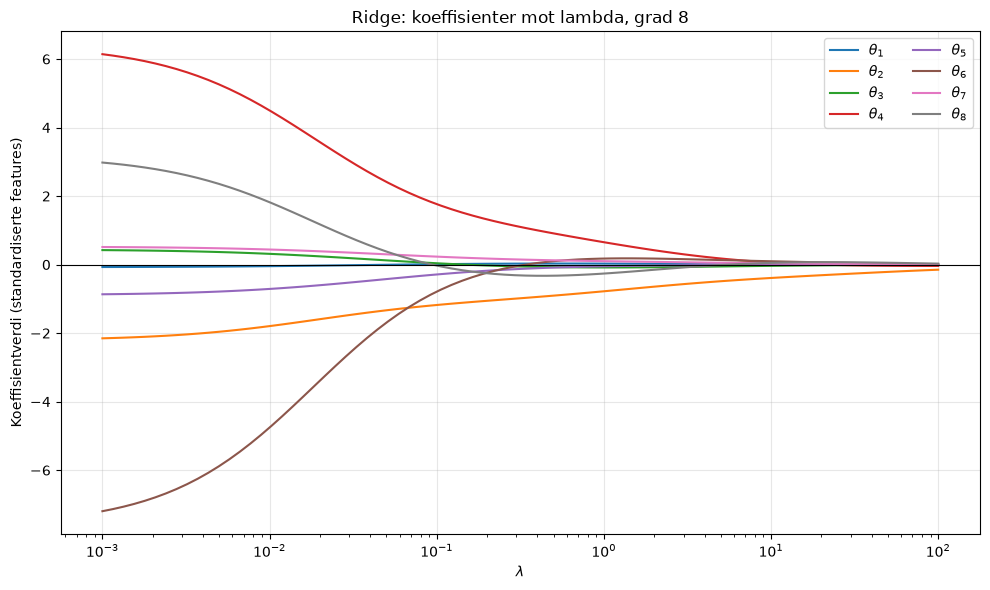

In [20]:
# Velg polynomgrad og regulariseringsverdier.
coef_degree = 8
coef_lambdas = np.logspace(-3, 2, 80) # -5 til -3 viser liten forskjell

X_coef = design_matrix(x, coef_degree)
X_coef_train, _, y_coef_train, _ = train_test_split(
    X_coef, y, test_size=0.3, random_state=2026
)

# Skalering basert kun på treningsdata.
coef_mean = X_coef_train.mean(axis=0)
coef_std = X_coef_train.std(axis=0)
coef_mean[0] = 0.0
coef_std[0] = 1.0

X_coef_scaled = (X_coef_train - coef_mean) / coef_std

# Konstantleddet skal ikke regulariseres.
coef_penalty = np.eye(coef_degree + 1)
coef_penalty[0, 0] = 0.0

coef_path = np.zeros((len(coef_lambdas), coef_degree + 1))

for i, lmb in enumerate(coef_lambdas):
    coef_path[i] = (
        np.linalg.pinv(
            X_coef_scaled.T @ X_coef_scaled + lmb * coef_penalty
        )
        @ X_coef_scaled.T @ y_coef_train
    )

fig, ax = plt.subplots(figsize=(10, 6))

# Vis de regulariserte koeffisientene theta_1, ..., theta_d.
for j in range(1, coef_degree + 1):
    ax.semilogx(
        coef_lambdas,
        coef_path[:, j],
        label=rf"$\theta_{{{j}}}$",
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    xlabel=r"$\lambda$",
    ylabel="Koeffisientverdi (standardiserte features)",
    title=f"Ridge: koeffisienter mot lambda, grad {coef_degree}",
)
ax.grid(alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

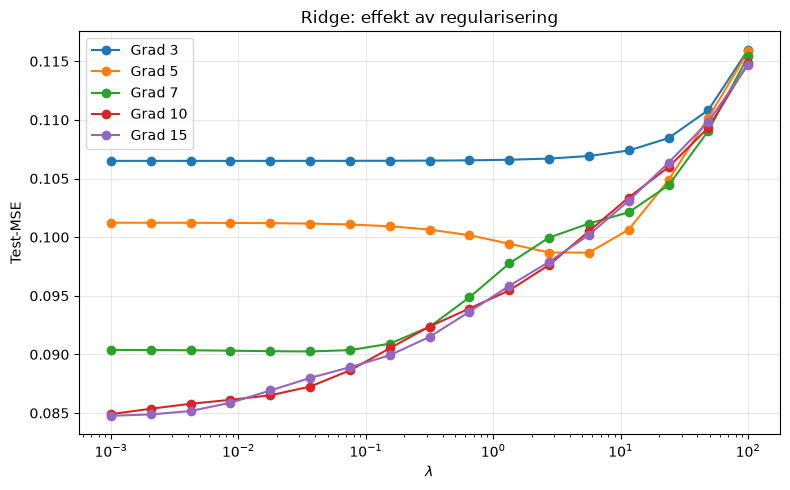

In [21]:
# Full AI
ridge_lambdas = np.logspace(-3, 2, 17) # -5 til -3 viser liten forskjell
ridge_degrees = [3, 5, 7, 10, 15]
ridge_mse = np.zeros((len(ridge_degrees), len(ridge_lambdas)))

for row, degree in enumerate(ridge_degrees):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=2026
    )

    # Lær skaleringen fra treningsdata.
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Behold konstantkolonnen.
    mean[0] = 0.0
    std[0] = 1.0

    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    # Ikke regulariser konstantleddet.
    penalty = np.eye(X_train_scaled.shape[1])
    penalty[0, 0] = 0.0

    for col, lmb in enumerate(ridge_lambdas):
        theta = (
            np.linalg.pinv(
                X_train_scaled.T @ X_train_scaled + lmb * penalty
            )
            @ X_train_scaled.T @ y_train
        )

        y_pred = X_test_scaled @ theta
        ridge_mse[row, col] = np.mean((y_test - y_pred)**2)

fig, ax = plt.subplots(figsize=(8, 5))

for row, degree in enumerate(ridge_degrees):
    ax.semilogx(
        ridge_lambdas,
        ridge_mse[row, :],
        marker="o",
        label=f"Grad {degree}",
    )

ax.set(
    xlabel=r"$\lambda$",
    ylabel="Test-MSE",
    title="Ridge: effekt av regularisering",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

# c: Bias-Variance Tradeoff

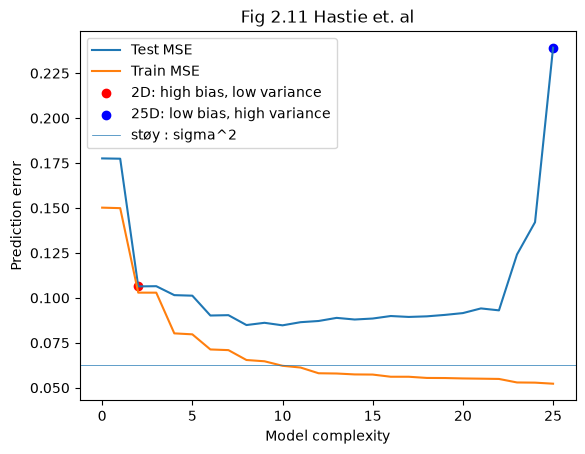

In [22]:
# Fig 2.11
MSE_test = []
MSE_train = []

maxdeg_bv = 25
deg_V_bv = np.arange(maxdeg_bv + 1)
for degree in range(maxdeg_bv + 1):
    X = design_matrix(x, degree)
    X_train, X_test, y_train, y_test = train_test_split(X,
    y, test_size=0.3, random_state=2026)

    theta = np.linalg.pinv(X_train) @ y_train
    Parameter_V.append(theta)

    y_predict_test = X_test @ theta
    y_predict_train = X_train @ theta
    # Here i create the data for figure 2.11
    mse_test = mean_squared_error(y_test, y_predict_test)
    MSE_test.append(mse_test)
    mse_train = mean_squared_error(y_train, y_predict_train)
    MSE_train.append(mse_train)


plt.plot(deg_V_bv, MSE_test, label = "Test MSE")
plt.plot(deg_V_bv, MSE_train, label = "Train MSE")
plt.title("Fig 2.11 Hastie et. al")
plt.xlabel("Model complexity")
plt.ylabel("Prediction error")
plt.scatter(deg_V_bv[2], MSE_test[2], color = "red", label = "2D: high bias, low variance")
plt.scatter(deg_V_bv[-1], MSE_test[-1], color = "blue",label = "25D: low bias, high variance")
plt.axhline(sigma**2, lw = 0.5, label = "støy : sigma^2")
plt.legend()
plt.show()

Grad 2 viser høy bias, ettersom treningsfeilen er relativt høy. Test error er omtrent lik treningserror, og betraktelig lavere enn for grad 1, som tilsier at det er relativt lav varians. 
Grad 25 viser lav bias, ettersom treningsfeilen er lav. Derimot er test error stor, noe som tilsier at det er høy varians.

# c: Bootstrap

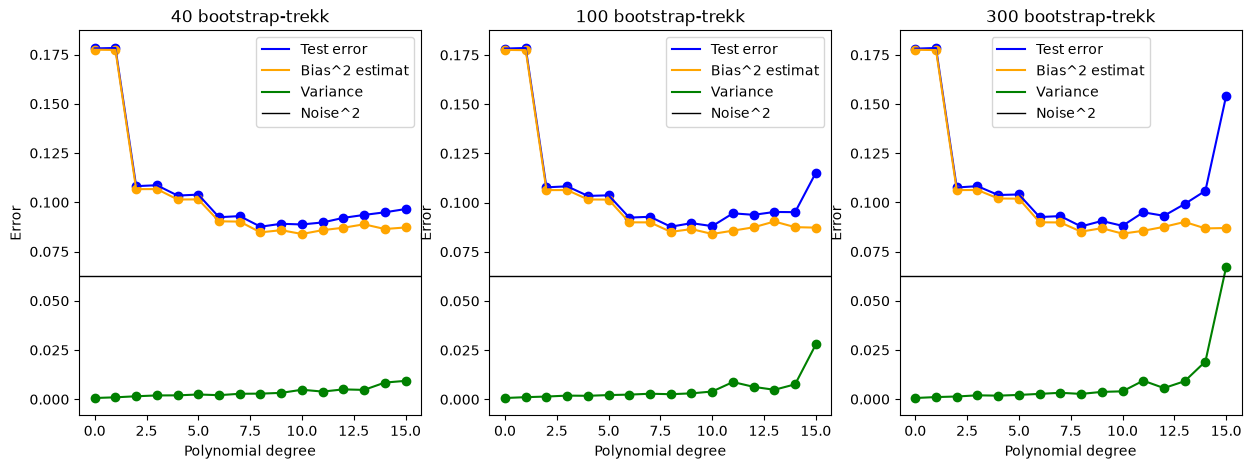

In [23]:
def bootstrap_bias_variance(n_bs, maxdeg, seed=2026):
    bootstrap_rng = np.random.default_rng(seed)
    bootstrap_seeds = bootstrap_rng.integers(
        0, 2**32 - 1, size=n_bs
    )

    error = np.zeros(maxdeg + 1)
    bias = np.zeros(maxdeg + 1)
    variance = np.zeros(maxdeg + 1)

    for degree in range(maxdeg + 1):
        X = design_matrix(x, degree)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=2026
        )
        y_pred = np.zeros((y_test.shape[0], n_bs))
        for i in range(n_bs):
            X_bs, y_bs = resample(
                X_train, y_train,
                random_state=int(bootstrap_seeds[i]),
            )
            theta = np.linalg.pinv(X_bs) @ y_bs

            y_pred[:, i] = X_test @ theta

        # Compare each test target with every bootstrap prediction for that point.
        error[degree] = np.mean((y_test[:, None] - y_pred)**2)
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1))
    
    return error, bias, variance 
bootstrap_maxdeg = 15

# 40 bootstrap-trekk
error40, bias40, variance40 = bootstrap_bias_variance(
    n_bs=40, maxdeg=bootstrap_maxdeg
)

# 100 bootstrap-trekk
error100, bias100, variance100 = bootstrap_bias_variance(
    n_bs=100, maxdeg=bootstrap_maxdeg
)

# 300 bootstrap-trekk
error300, bias300, variance300 = bootstrap_bias_variance(
    n_bs=300, maxdeg=bootstrap_maxdeg
)

degree_vec = np.arange(bootstrap_maxdeg + 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

results = [
    (error40, bias40, variance40, 40),
    (error100, bias100, variance100, 100),
    (error300, bias300, variance300, 300)
]

for i, (error, bias, variance, n_bootstrap) in enumerate(results):

    ax[i].plot(degree_vec, error, label="Test error", color="blue")
    ax[i].scatter(degree_vec, error, color="blue")

    ax[i].plot(degree_vec, bias, label="Bias^2 estimat", color="orange")
    ax[i].scatter(degree_vec, bias, color="orange")

    ax[i].plot(degree_vec, variance, label="Variance", color="green")
    ax[i].scatter(degree_vec, variance, color="green")

    ax[i].axhline(y=sigma**2, label = "Noise^2", color="black", linestyle="-", linewidth=1)

    ax[i].set_title(f"{n_bootstrap} bootstrap-trekk")
    ax[i].set_xlabel("Polynomial degree")
    ax[i].set_ylabel("Error")
    ax[i].legend()
    #ax[i].set_ylim(0, 0.5)

#plt.tight_layout()
plt.show()

# d: K Fold Cross Validation

OLS, k=5: maximum absolute MSE difference = 5.371e-15
Ridge, k=5, lambda=0.01: maximum absolute MSE difference = 2.423e-14
Ridge, k=5, lambda=0.1: maximum absolute MSE difference = 5.385e-15
Ridge, k=5, lambda=0.5: maximum absolute MSE difference = 8.465e-16
Ridge, k=5, lambda=1: maximum absolute MSE difference = 4.996e-16
Ridge, k=5, lambda=10: maximum absolute MSE difference = 1.249e-16
OLS, k=10: maximum absolute MSE difference = 1.005e-14
Ridge, k=10, lambda=0.01: maximum absolute MSE difference = 3.969e-14
Ridge, k=10, lambda=0.1: maximum absolute MSE difference = 2.970e-15
Ridge, k=10, lambda=0.5: maximum absolute MSE difference = 3.608e-16
Ridge, k=10, lambda=1: maximum absolute MSE difference = 4.580e-16
Ridge, k=10, lambda=10: maximum absolute MSE difference = 5.551e-17


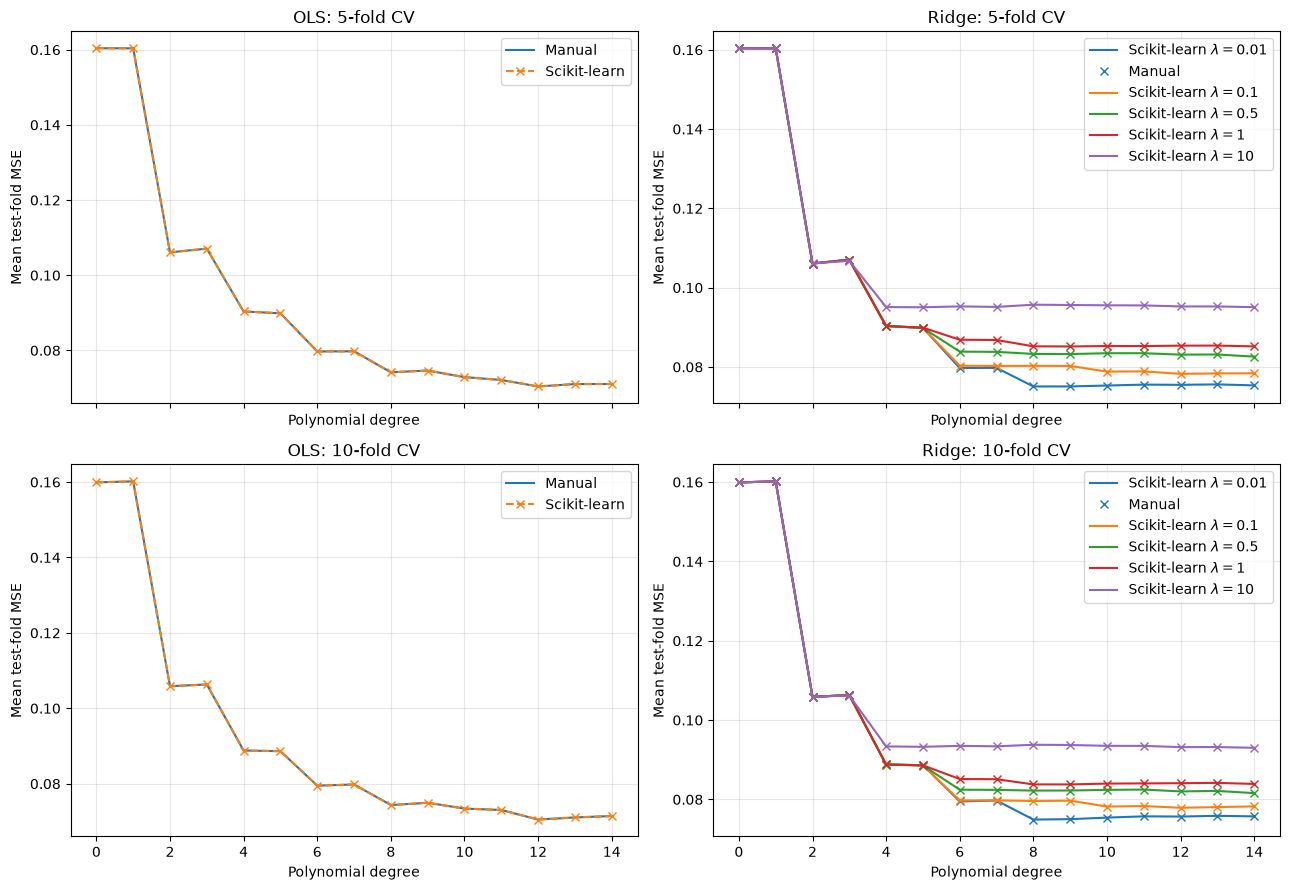

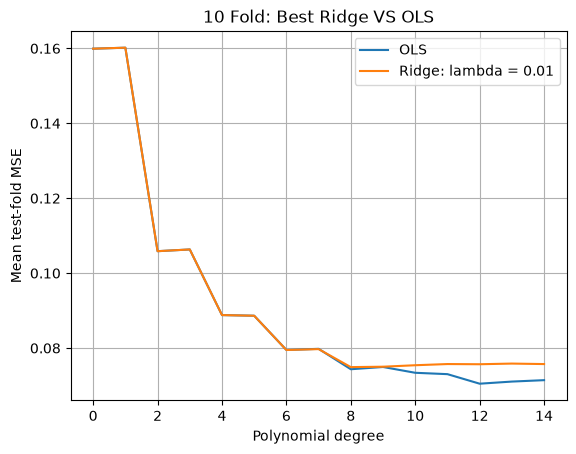

In [24]:
def Kfold_CV(k, deg, lmb=0): # OLS med mindre lmb blir gitt verdi
    X = design_matrix(x, deg)
    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    score_KFold = []
    
    for train_ind, test_ind in kfold.split(X):
        x_train, x_test = X[train_ind], X[test_ind]
        y_train, y_test = y[train_ind], y[test_ind]

        # Skalering
        # Beregn gjennomsnitt og standardavvik fra treningsdata
        mean = x_train.mean(axis=0)
        std = x_train.std(axis=0)

        # Behold konstantkolonnen intercept: (1 - 0) / 1 = 1
        mean[0] = 0
        std[0] = 1

        X_train_norm = (x_train - mean) / std
        X_test_norm = (x_test - mean) / std
        # Trenger ikke sentrere y da design matrisen inneholder intercept

        I = np.eye(X_train_norm.shape[1])
        I[0,0] = 0.0 # Vil ikke straffe intercept i Ridge regresjon

        if lmb == 0:
            theta = np.linalg.pinv(X_train_norm) @ y_train
        else:
            theta = (
                np.linalg.pinv(X_train_norm.T @ X_train_norm + lmb * I)
                @ X_train_norm.T @ y_train)

        y_predict = X_test_norm @ theta 
        mse = np.mean((y_test - y_predict)**2)
        score_KFold.append(mse)
    mse_Kfold = np.mean(score_KFold)
    mse_std = np.std(score_KFold, ddof=1)
    return mse_Kfold, mse_std


def sklearn_kfold(folds, degree, lmb=None):
    X = design_matrix(x, degree)
    cv = KFold(n_splits=folds, shuffle=True, random_state=2026)

    if lmb is None:
        # X already includes the constant column.
        model = LinearRegression(fit_intercept=False)
    else:
        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=lmb, fit_intercept=True, solver="svd")
        )

    fold_mse = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring="neg_mean_squared_error",
        error_score="raise"
    )

    return fold_mse.mean(), fold_mse.std(ddof=1)

degrees = np.arange(maxdeg)
lambdas = [1e-2, 1e-1,0.5, 1.0, 1e1]
mse_KFold_list = []
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)

for row, folds in enumerate([5, 10]):
    # OLS
    manual = np.array([
        Kfold_CV(folds, degree, 0)[0]
        for degree in degrees
    ])
    std = np.array([
        Kfold_CV(folds, degree, 0)[1]
        for degree in degrees
    ])
    sklearn_mse = np.array([
        sklearn_kfold(folds, degree)[0]
        for degree in degrees
    ])

    ax = axes[row, 0]
    ax.plot(degrees, manual, label="Manual")
    ax.plot(degrees, sklearn_mse, "x--", label="Scikit-learn")
    ax.set_title(f"OLS: {folds}-fold CV")
    print(
        f"OLS, k={folds}: maximum absolute MSE difference = "
        f"{np.max(np.abs(manual - sklearn_mse)):.3e}"
    )

    # Ridge: one curve per lambda
    ax = axes[row, 1]
    for lmb in lambdas:
        manual = np.array([
            Kfold_CV(folds, degree, lmb)[0]
            for degree in degrees
        ])
        sklearn_mse = np.array([
            sklearn_kfold(folds, degree, lmb)[0]
            for degree in degrees
        ])

        line, = ax.plot(
            degrees, sklearn_mse,
            label=rf"Scikit-learn $\lambda={lmb:g}$"
        )
        ax.plot(
            degrees, manual, "x", color=line.get_color(),
            label="Manual" if lmb == lambdas[0] else "_nolegend_"
        )
        print(
            f"Ridge, k={folds}, lambda={lmb:g}: "
            f"maximum absolute MSE difference = "
            f"{np.max(np.abs(manual - sklearn_mse)):.3e}"
        )
    ax.set_title(f"Ridge: {folds}-fold CV")

for ax in axes.flat:
    ax.set_xlabel("Polynomial degree")
    ax.set_ylabel("Mean test-fold MSE")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

ols = manual = np.array([
            Kfold_CV(10, degree, 0.0)[0]
            for degree in degrees])
ridge = np.array([
            Kfold_CV(10, degree, 0.01)[0]
            for degree in degrees])

plt.plot(degrees, ols, label = "OLS")
plt.plot(degrees, ridge, label = "Ridge: lambda = 0.01")
plt.title("10 Fold: Best Ridge VS OLS")
plt.legend()
plt.xlabel("Polynomial degree")
plt.ylabel("Mean test-fold MSE")
plt.grid()
plt.show()

Below 5 degree polynomial: OLS equals Ridge in accuracy. Above 5 degrees the only lambda which gives ridge a lower MSE is 0.01 above 10 degrees, else OLS gives a lower MSE than ridge for all tested lambda values. 
### Problemet 
med denne koden er at den tester Scikit mot manuell løsning. Jeg tror ikke DET er hovedpoenget med koden. Jeg lar det gli for nå. En viktig ting er at jeg kan tolke masse utifra plottene. 

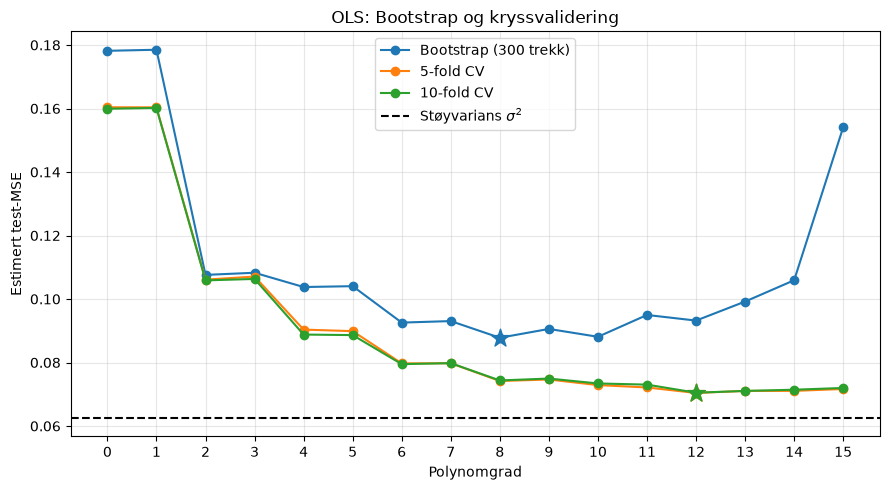

,Beste polynomgrad,Laveste estimert MSE
Metode,,
Bootstrap (300 trekk),8,0.087795
5-fold CV,12,0.070415
10-fold CV,12,0.070490


In [25]:
# Plot CV vs Bootstrap her
# Kjør bootstrap-cellen og K-fold-cellen før denne cellen.
comparison_degrees = np.arange(len(error300))

cv5_mse = np.array([
    Kfold_CV(5, degree, lmb=0)[0]
    for degree in comparison_degrees
])
cv10_mse = np.array([
    Kfold_CV(10, degree, lmb=0)[0]
    for degree in comparison_degrees
])

comparison_results = {
    "Bootstrap (300 trekk)": error300,
    "5-fold CV": cv5_mse,
    "10-fold CV": cv10_mse,
}

fig, ax = plt.subplots(figsize=(9, 5))
summary_rows = []

for method, errors in comparison_results.items():
    best_index = np.argmin(errors)
    best_degree = comparison_degrees[best_index]

    line, = ax.plot(
        comparison_degrees, errors, marker="o", label=method
    )
    ax.scatter(
        best_degree, errors[best_index],
        marker="*", s=180, color=line.get_color(), zorder=3
    )

    summary_rows.append({
        "Metode": method,
        "Beste polynomgrad": int(best_degree),
        "Laveste estimert MSE": errors[best_index],
    })

ax.axhline(
    sigma**2, color="black", linestyle="--",
    label=r"Støyvarians $\sigma^2$"
)
ax.set(
    title="OLS: Bootstrap og kryssvalidering",
    xlabel="Polynomgrad",
    ylabel="Estimert test-MSE",
)
ax.set_xticks(comparison_degrees)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows).set_index("Metode"))

# g: Lasso gradient Descent

# i: Final comparison of OLS, Ridge and Lasso using cross validation

In [ ]:
"""#Tillegg(8) Skrekkelig stor kode
degrees_i = np.arange(16)
ridge_lambdas_i = np.logspace(-4, 2, 13)
lasso_lambdas_i = np.logspace(-4, 0, 9)

# Samme foldinndeling brukes for alle modeller.
cv_i = KFold(n_splits=10, shuffle=True, random_state=2026)
rows_i = []

for degree in degrees_i:
    X_i = design_matrix(x, degree)

    candidates_i = [("OLS", np.nan, LinearRegression())]

    candidates_i += [
        ("Ridge", lmb, Ridge(alpha=lmb, solver="svd"))
        for lmb in ridge_lambdas_i
    ]

    candidates_i += [
        (
            "Lasso",
            lmb,
            #ENDRET(10)
            Lasso(alpha=lmb / 2, max_iter=5_000_000, tol=1e-6),
        )
        for lmb in lasso_lambdas_i
    ]

    for method, lmb, estimator in candidates_i:
        # Skaleringen læres bare fra treningsfolden.
        # Konstantkolonnen blir null etter sentrering;
        # estimatorens eget intercept tar over konstantleddet.
        pipeline_i = make_pipeline(StandardScaler(), estimator)

        # Stopp ved manglende konvergens, slik at en uferdig
        # Lasso-løsning ikke brukes ukritisk i modellutvelgelsen.
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            fold_mse = -cross_val_score(
                pipeline_i,
                X_i,
                y,
                cv=cv_i,
                scoring="neg_mean_squared_error",
                error_score="raise",
            )

        rows_i.append({
            "Metode": method,
            "Grad": degree,
            "Lambda": lmb,
            "CV-MSE": fold_mse.mean(),
            "Fold-standardavvik": fold_mse.std(ddof=1),
        })

results_i = pd.DataFrame(rows_i)

#Tillegg(9)
best_indices_i = results_i.groupby("Metode")["CV-MSE"].idxmin()

best_models_i = (
    results_i.loc[best_indices_i]
    .sort_values("CV-MSE")
    .reset_index(drop=True)
)

display(best_models_i)

winner_i = best_models_i.iloc[0]

print(
    f"Lavest CV-MSE blant undersøkte modeller: "
    f"{winner_i['Metode']}, grad {int(winner_i['Grad'])}, "
    f"CV-MSE = {winner_i['CV-MSE']:.6f}"
)

if winner_i["Metode"] != "OLS":
    print(f"Lambda = {winner_i['Lambda']:.6g}")

#Tillegg(10)
best_per_degree_i = (
    results_i.groupby(["Metode", "Grad"])["CV-MSE"]
    .min()
    .unstack("Metode")
)

fig, ax = plt.subplots(figsize=(9, 5))

for method in ["OLS", "Ridge", "Lasso"]:
    ax.plot(
        best_per_degree_i.index,
        best_per_degree_i[method],
        marker="o",
        label=method,
    )

ax.set(
    title="10-fold CV: beste undersøkte lambda ved hver grad",
    xlabel="Polynomgrad",
    ylabel="Gjennomsnittlig CV-MSE",
)
ax.set_xticks(degrees_i)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()"""


KeyboardInterrupt: 